# RQ1 — Identifiability & Coefficient Stability

**Research Question:** To what extent can MNNs uniquely and reliably identify the true underlying governing equations from noisy, sparse, or partially observed data? How stable are the learned ODE coefficients α with respect to perturbations in input data and variations in the training process?

| Exp | System | α inspected |
|---|---|---|
| E1: Noise sweep | Damped sine | `Sine.coeffs` shape `(n_dim, n_step, order+1)` |
| E2: Sparsity sweep | Damped sine | same |
| E3: Seed stability | Damped sine | variance of α across N independent runs |
| E4: Stability regularisation | Damped sine | coeff variance with/without penalty |
| E5: Time-inv vs time-var | Two-body | `EPHModel.coeff_param` |

In [1]:
import sys, os, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import pytorch_lightning as pl
import warnings
warnings.filterwarnings('ignore')

# ── Set this to your mech-nn-master directory ────────────────────────
REPO_ROOT = '/Users/dorinai/Downloads/mech-nn-master'
sys.path.insert(0, REPO_ROOT)

from solver.ode_layer import ODEINDLayer
from fit.sine import SineDataset, SineDataModule, Method as SineMethod, Sine
import nbody.two_body_multi_sparse_sys          as tv_module
import nbody.two_body_multi_sparse_sys_time_ind as ti_module

torch.set_printoptions(precision=6, linewidth=200, sci_mode=False)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('rq1_results', exist_ok=True)
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Using double precision solver
Building block diagonal A
run, logs/3, 3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


run, logs/4, 4
run, logs/4, 4


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Device: cpu  |  PyTorch: 2.2.2


---
## Setup: Parameterised Sine Dataset & Flexible Model

`sine.py`'s `SineDataset` has a fixed noise level. We subclass it to allow controlled noise and temporal downsampling.

In [2]:
class ControlledSineDataset(SineDataset):
    """
    Extends SineDataset with controllable noise_std, subsampling, and seed.
    Signal: y(t) = sin(2t)*exp(-0.1t) + noise_std*N(0,1)
    Identical functional form to sine.py.
    """
    def __init__(self, end=50.0, n_step=500, noise_std=0.5, subsample=1, seed=0):
        rng = np.random.default_rng(seed)
        t     = np.linspace(0, end, n_step)
        damp  = np.exp(-0.1 * t)
        clean = np.sin(2 * t) * damp
        noisy = clean + noise_std * rng.standard_normal(n_step)
        self.clean = torch.tensor(clean[::subsample], dtype=torch.float64)
        self.y     = torch.tensor(noisy[::subsample], dtype=torch.float64)
        self.t     = torch.tensor(t[::subsample],     dtype=torch.float64)

    def __len__(self):       return 1
    def __getitem__(self, _): return self.y


class FlexSine(Sine):
    """
    Sine with configurable n_step for subsampled data.
    All solver params (order=2, n_dim=1, bs=1, float64) identical to sine.py.
    """
    def __init__(self, n_step=500, seed=0):
        nn.Module.__init__(self)
        torch.manual_seed(seed)
        np.random.seed(seed)
        self.step_size = 0.1
        self.end       = n_step * self.step_size
        self.n_step    = n_step
        self.order     = 2
        self.n_dim     = 1
        self.bs        = 1
        self.n_iv      = 0
        self.iv_rhs    = None
        dtype = torch.float64
        self.coeffs = nn.Parameter(
            torch.tensor(np.random.random((self.n_dim, n_step, self.order+1)), dtype=dtype))
        self.rhs   = torch.ones(1, 1, n_step, dtype=dtype)
        self.steps = nn.Parameter(
            torch.logit(self.step_size * torch.ones(1, n_step-1, self.n_dim)))
        self.ode = ODEINDLayer(
            bs=self.bs, order=self.order, n_ind_dim=self.n_dim,
            n_iv=self.n_iv, n_step=n_step, n_iv_steps=1)


class FlexMethod(SineMethod):
    """SineMethod wrapping FlexSine; tracks per-step loss."""
    def __init__(self, n_step=500, lr=0.01, seed=0):
        pl.LightningModule.__init__(self)
        self.learning_rate = lr
        self.model         = FlexSine(n_step=n_step, seed=seed)
        self.func_list = []; self.y_list = []
        self.funcp_list = []; self.funcpp_list = []; self.steps_list = []
        self._loss_history = []

    def training_step(self, batch, batch_idx):
        result = super().training_step(batch, batch_idx)
        self._loss_history.append(result['loss'].item())
        return result


def make_trainer(n_epochs, silent=True):
    return pl.Trainer(
        max_epochs=n_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1, enable_progress_bar=not silent,
        enable_model_summary=False, log_every_n_steps=1)


def train_sine(n_step, dataset, n_epochs=300, lr=0.01, seed=0):
    """Train FlexMethod; returns (method, mse_vs_clean, loss_history)."""
    method     = FlexMethod(n_step=n_step, lr=lr, seed=seed)
    datamodule = SineDataModule(dataset)
    make_trainer(n_epochs).fit(method, datamodule=datamodule)
    method.eval()
    with torch.no_grad():
        _, u0, *_ = method()
    pred = u0.squeeze().float().cpu()
    tgt  = dataset.clean.float().cpu()
    L    = min(pred.shape[0], tgt.shape[0])
    return method, float(((pred[:L]-tgt[:L])**2).mean()), method._loss_history


# Smoke test
_ds = ControlledSineDataset(n_step=50, noise_std=0.5, seed=0)
_m  = FlexMethod(n_step=50, seed=0)
with torch.no_grad(): _, u0, *_ = _m()
print(f'FlexSine smoke test: u0.shape={u0.shape}  ok')

Using double precision solver
Building block diagonal A
FlexSine smoke test: u0.shape=torch.Size([1, 1, 50])  ok


---
## E1 — Noise Sweep
sigma in {0, 0.1, 0.3, 0.5, 1.0, 2.0} x N_SEEDS seeds. Records MSE and coefficient variance.

In [3]:
NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]
N_SEEDS  = 5
N_STEP   = 500
N_EPOCHS = 300

e1_records = []
e1_coeffs  = {}   # noise -> (N_SEEDS, n_flat)

for noise in NOISE_LEVELS:
    sc = []
    for seed in range(N_SEEDS):
        ds = ControlledSineDataset(n_step=N_STEP, noise_std=noise, seed=seed)
        m, mse, _ = train_sine(N_STEP, ds, n_epochs=N_EPOCHS, seed=seed)
        alpha = m.model.coeffs.detach().cpu().numpy().flatten()
        sc.append(alpha)
        e1_records.append({'noise_std': noise, 'seed': seed, 'mse': mse})
        print(f'  noise={noise:.2f}  seed={seed}  mse={mse:.6f}')
    e1_coeffs[noise] = np.stack(sc)

df_e1 = pd.DataFrame(e1_records)
df_e1g = df_e1.groupby('noise_std').agg(
    mse_mean=('mse','mean'), mse_std=('mse','std')).reset_index()
df_e1g['coeff_var'] = [float(e1_coeffs[n].var(axis=0).mean()) for n in df_e1g.noise_std]
df_e1g.to_csv('rq1_results/e1_noise_sweep.csv', index=False)
print('\n', df_e1g.to_string(index=False))

Using double precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=300` reached.


  noise=0.00  seed=0  mse=0.000694
Using double precision solver


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Building block diagonal A


...

  noise=2.00  seed=2  mse=1.324266
Using double precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=300` reached.


  noise=2.00  seed=3  mse=1.322010
Using double precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=300` reached.


  noise=2.00  seed=4  mse=1.196799

  noise_std  mse_mean  mse_std  coeff_var
       0.0  0.001160 0.000882   0.121264
       0.1  0.002692 0.001053   0.121737
       0.3  0.016252 0.002371   0.125933
       0.5  0.048115 0.007380   0.132536
       1.0  0.223744 0.037850   0.162029
       2.0  1.167613 0.198854   0.217865


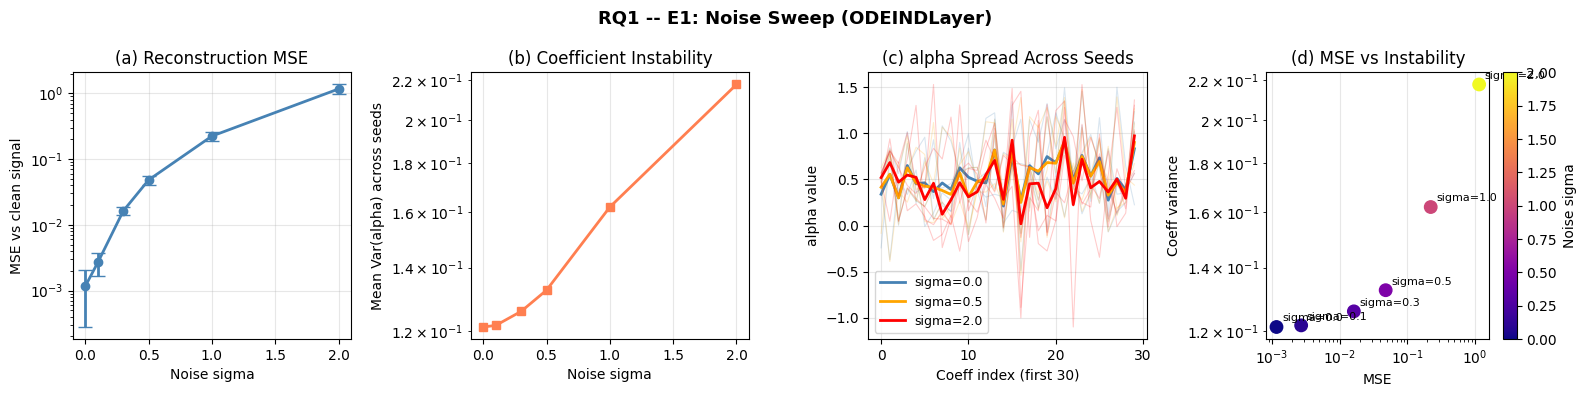

In [4]:
fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 4, figure=fig)
ax = fig.add_subplot(gs[0])
ax.errorbar(df_e1g.noise_std, df_e1g.mse_mean, yerr=df_e1g.mse_std,
            marker='o', color='steelblue', capsize=5, linewidth=2)
ax.set(xlabel='Noise sigma', ylabel='MSE vs clean signal', yscale='log',
       title='(a) Reconstruction MSE'); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1])
ax.plot(df_e1g.noise_std, df_e1g.coeff_var, marker='s', color='coral', linewidth=2)
ax.set(xlabel='Noise sigma', ylabel='Mean Var(alpha) across seeds', yscale='log',
       title='(b) Coefficient Instability'); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[2])
for n, col in zip([0.0, 0.5, 2.0], ['steelblue','orange','red']):
    arr = e1_coeffs[n][:, :30]
    for row in arr: ax.plot(row, alpha=0.2, color=col, linewidth=0.8)
    ax.plot(arr.mean(axis=0), color=col, linewidth=2, label=f'sigma={n}')
ax.set(xlabel='Coeff index (first 30)', ylabel='alpha value',
       title='(c) alpha Spread Across Seeds'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[3])
sc = ax.scatter(df_e1g.mse_mean, df_e1g.coeff_var,
                c=df_e1g.noise_std, cmap='plasma', s=80, zorder=3)
for _, r in df_e1g.iterrows():
    ax.annotate(f'sigma={r.noise_std}', (r.mse_mean, r.coeff_var),
                fontsize=8, xytext=(4,4), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Noise sigma')
ax.set(xlabel='MSE', ylabel='Coeff variance', xscale='log', yscale='log',
       title='(d) MSE vs Instability'); ax.grid(True, alpha=0.3)

fig.suptitle('RQ1 -- E1: Noise Sweep (ODEINDLayer)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq1_results/e1_noise_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E2 — Sparsity Sweep
Subsample in {1,2,4,8} -> T = {500, 250, 125, 62} time points. FlexSine is rebuilt at each T.

In [5]:
SUBSAMPLE_FACTORS = [1, 2, 4, 8]

e2_records = []
e2_coeffs  = {}

for sub in SUBSAMPLE_FACTORS:
    sc = []
    for seed in range(N_SEEDS):
        ds = ControlledSineDataset(n_step=N_STEP, noise_std=0.5, subsample=sub, seed=seed)
        T  = ds.y.shape[0]
        m, mse, _ = train_sine(T, ds, n_epochs=N_EPOCHS, seed=seed)
        alpha = m.model.coeffs.detach().cpu().numpy().flatten()
        sc.append(alpha)
        e2_records.append({'subsample': sub, 'n_steps': T, 'seed': seed, 'mse': mse})
        print(f'  sub={sub}  T={T}  seed={seed}  mse={mse:.6f}')
    e2_coeffs[sub] = np.stack(sc)

df_e2 = pd.DataFrame(e2_records)
df_e2g = df_e2.groupby(['subsample','n_steps']).agg(
    mse_mean=('mse','mean'), mse_std=('mse','std')).reset_index()
df_e2g['coeff_var'] = [float(e2_coeffs[r.subsample].var(axis=0).mean())
                       for _, r in df_e2g.iterrows()]
df_e2g.to_csv('rq1_results/e2_sparsity_sweep.csv', index=False)
print('\n', df_e2g.to_string(index=False))

Using double precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec

  sub=1  T=500  seed=0  mse=0.049764
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  sub=1  T=500  seed=1  mse=0.035118
Using double precision solver
Building block diagonal A


...

  sub=8  T=63  seed=2  mse=0.085853
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  sub=8  T=63  seed=3  mse=0.083912
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.


  sub=8  T=63  seed=4  mse=0.083642

  subsample  n_steps  mse_mean  mse_std  coeff_var
         1      500  0.048115 0.007380   0.132536
         2      250  0.064549 0.012856   0.130751
         4      125  0.082946 0.011218   0.122576
         8       63  0.083036 0.009148   0.119739


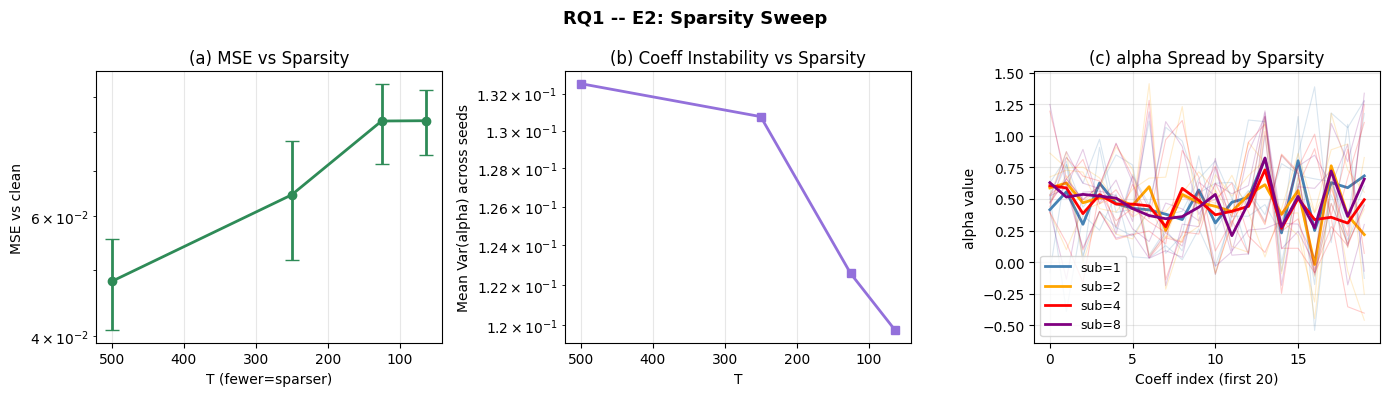

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ax = axes[0]
ax.errorbar(df_e2g.n_steps, df_e2g.mse_mean, yerr=df_e2g.mse_std,
            marker='o', color='seagreen', capsize=5, linewidth=2)
ax.invert_xaxis()
ax.set(xlabel='T (fewer=sparser)', ylabel='MSE vs clean', yscale='log',
       title='(a) MSE vs Sparsity'); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_e2g.n_steps, df_e2g.coeff_var, marker='s', color='mediumpurple', linewidth=2)
ax.invert_xaxis()
ax.set(xlabel='T', ylabel='Mean Var(alpha) across seeds', yscale='log',
       title='(b) Coeff Instability vs Sparsity'); ax.grid(True, alpha=0.3)

ax = axes[2]
colors_sub = {1:'steelblue', 2:'orange', 4:'red', 8:'purple'}
for sub in SUBSAMPLE_FACTORS:
    arr = e2_coeffs[sub]; n = min(20, arr.shape[1])
    for row in arr: ax.plot(row[:n], alpha=0.2, color=colors_sub[sub], linewidth=0.8)
    ax.plot(arr[:,:n].mean(axis=0), color=colors_sub[sub], linewidth=2,
            label=f'sub={sub}')
ax.set(xlabel='Coeff index (first 20)', ylabel='alpha value', title='(c) alpha Spread by Sparsity')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('RQ1 -- E2: Sparsity Sweep', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq1_results/e2_sparsity_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E3 — Coefficient Stability Across Seeds

**Same dataset, different random initialisations.** If MNN is identifiable, all seeds must converge to the same alpha.

Metrics: std(alpha), CV = std/|mean|, pairwise cosine similarity of alpha vectors.

In [7]:
N_STAB_SEEDS = 8
ds_e3 = ControlledSineDataset(n_step=N_STEP, noise_std=0.5, seed=999)

e3_coeffs, e3_mses, e3_steps_list = [], [], []

for seed in range(N_STAB_SEEDS):
    m, mse, _ = train_sine(N_STEP, ds_e3, n_epochs=N_EPOCHS, seed=seed)
    alpha  = m.model.coeffs.detach().cpu().numpy().flatten()
    sv     = torch.sigmoid(m.model.steps).detach().cpu().numpy().flatten()
    e3_coeffs.append(alpha); e3_mses.append(mse); e3_steps_list.append(sv)
    print(f'  Seed {seed}: mse={mse:.6f}  |alpha|_mean={np.abs(alpha).mean():.4f}')

e3_coeffs = np.stack(e3_coeffs)
e3_steps  = np.stack(e3_steps_list)
c_mean = e3_coeffs.mean(axis=0)
c_std  = e3_coeffs.std(axis=0)
c_var  = e3_coeffs.var(axis=0)
cv     = c_std / (np.abs(c_mean) + 1e-8)
normed = e3_coeffs / (np.linalg.norm(e3_coeffs, axis=1, keepdims=True) + 1e-12)
cos_sim = normed @ normed.T

print(f'\nE3 Summary ({N_STAB_SEEDS} seeds, same data, sigma=0.5):')
print(f'  MSE:           mean={np.mean(e3_mses):.6f}  std={np.std(e3_mses):.6f}')
print(f'  Coeff std:     mean={c_std.mean():.6f}  max={c_std.max():.6f}')
print(f'  Coeff var:     mean={c_var.mean():.8f}')
print(f'  CV (std/|mu|): mean={cv.mean():.4f}  max={cv.max():.4f}')
mask = ~np.eye(N_STAB_SEEDS, dtype=bool)
print(f'  Cosine sim:    mean(off-diag)={cos_sim[mask].mean():.6f}')
np.save('rq1_results/e3_coeffs.npy', e3_coeffs)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Seed 0: mse=0.049658  |alpha|_mean=0.5591
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

  Seed 5: mse=0.046502  |alpha|_mean=0.5777
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.


  Seed 6: mse=0.045026  |alpha|_mean=0.5793
Using double precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=300` reached.


  Seed 7: mse=0.051185  |alpha|_mean=0.5650

E3 Summary (8 seeds, same data, sigma=0.5):
  MSE:           mean=0.048807  std=0.003526
  Coeff std:     mean=0.369175  max=0.742472
  Coeff var:     mean=0.14504485
  CV (std/|mu|): mean=0.8020  max=18.2181
  Cosine sim:    mean(off-diag)=0.634760


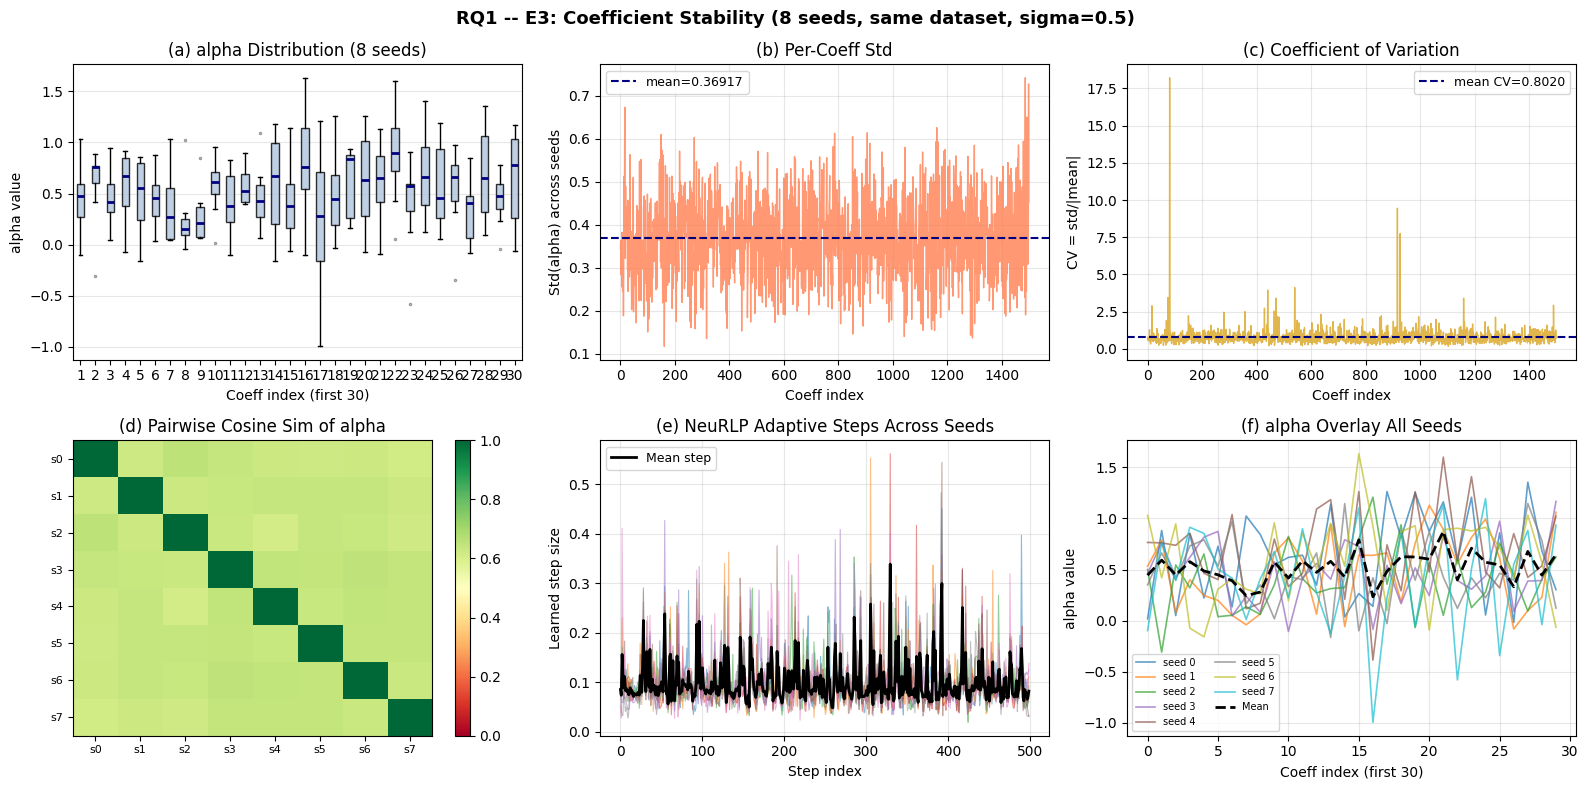

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
N_SHOW = 30

ax = axes[0,0]
ax.boxplot(e3_coeffs[:, :N_SHOW], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
           medianprops=dict(color='navy', linewidth=2),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set(xlabel='Coeff index (first 30)', ylabel='alpha value',
       title=f'(a) alpha Distribution ({N_STAB_SEEDS} seeds)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[0,1]
ax.plot(c_std, color='coral', linewidth=1, alpha=0.8)
ax.axhline(c_std.mean(), linestyle='--', color='navy', linewidth=1.5,
           label=f'mean={c_std.mean():.5f}')
ax.set(xlabel='Coeff index', ylabel='Std(alpha) across seeds', title='(b) Per-Coeff Std')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0,2]
ax.plot(cv, color='goldenrod', linewidth=1, alpha=0.8)
ax.axhline(cv.mean(), linestyle='--', color='navy', linewidth=1.5,
           label=f'mean CV={cv.mean():.4f}')
ax.set(xlabel='Coeff index', ylabel='CV = std/|mean|', title='(c) Coefficient of Variation')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1,0]
im = ax.imshow(cos_sim, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(N_STAB_SEEDS)); ax.set_yticks(range(N_STAB_SEEDS))
ax.set_xticklabels([f's{i}' for i in range(N_STAB_SEEDS)], fontsize=8)
ax.set_yticklabels([f's{i}' for i in range(N_STAB_SEEDS)], fontsize=8)
ax.set_title('(d) Pairwise Cosine Sim of alpha')

ax = axes[1,1]
for sv in e3_steps: ax.plot(sv, alpha=0.5, linewidth=0.8)
ax.plot(e3_steps.mean(axis=0), 'k-', linewidth=2, label='Mean step')
ax.set(xlabel='Step index', ylabel='Learned step size',
       title='(e) NeuRLP Adaptive Steps Across Seeds')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1,2]
cmap_s = plt.cm.tab10(np.linspace(0, 1, N_STAB_SEEDS))
for i, row in enumerate(e3_coeffs):
    ax.plot(row[:N_SHOW], color=cmap_s[i], alpha=0.7, linewidth=1.2, label=f'seed {i}')
ax.plot(c_mean[:N_SHOW], 'k--', linewidth=2, label='Mean')
ax.set(xlabel='Coeff index (first 30)', ylabel='alpha value', title='(f) alpha Overlay All Seeds')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

fig.suptitle(f'RQ1 -- E3: Coefficient Stability ({N_STAB_SEEDS} seeds, same dataset, sigma=0.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq1_results/e3_coefficient_stability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E4 — Stability Regularisation

Loss = ||u0 - y||^2 + lambda * ||alpha_t - alpha_{t-1}||^2

Penalises large changes in alpha between consecutive gradient steps.

In [9]:
class StabMethod(FlexMethod):
    def __init__(self, n_step=500, lr=0.01, seed=0, lambda_stab=0.0, noise_aug=0.0):
        super().__init__(n_step=n_step, lr=lr, seed=seed)
        self.lambda_stab = lambda_stab
        self.noise_aug   = noise_aug
        self._prev_alpha = None

    def training_step(self, batch, batch_idx):
        y = batch
        if self.noise_aug > 0:
            y = y + self.noise_aug * torch.randn_like(y)
        eps, u0, u1, u2, steps = self()
        recon = (u0 - y).pow(2).sum()
        stab  = torch.tensor(0.0, device=self.device)
        if self.lambda_stab > 0 and self._prev_alpha is not None:
            stab = self.lambda_stab * (self.model.coeffs - self._prev_alpha).pow(2).mean()
        self._prev_alpha = self.model.coeffs.detach().clone()
        loss = recon + stab
        self.log('train_loss', loss, prog_bar=True)
        self.log('stab_loss',  stab, prog_bar=True)
        self._loss_history.append(loss.item())
        self.func_list.append(u0.detach().cpu().numpy())
        self.y_list.append(y.detach().cpu().numpy())
        return loss


LAMBDA_VALUES = [0.0, 0.01, 0.1, 0.5]
ds_e4 = ControlledSineDataset(n_step=N_STEP, noise_std=0.5, seed=999)
e4 = {}

for lam in LAMBDA_VALUES:
    sc, ms = [], []
    for seed in range(N_SEEDS):
        m = StabMethod(n_step=N_STEP, lr=0.01, seed=seed,
                       lambda_stab=lam, noise_aug=0.3 if lam > 0 else 0.0)
        make_trainer(N_EPOCHS).fit(m, datamodule=SineDataModule(ds_e4))
        m.eval()
        with torch.no_grad(): _, u0, *_ = m()
        pred = u0.squeeze().float().cpu(); tgt = ds_e4.clean.float().cpu()
        L = min(pred.shape[0], tgt.shape[0])
        mse = float(((pred[:L]-tgt[:L])**2).mean())
        sc.append(m.model.coeffs.detach().cpu().numpy().flatten())
        ms.append(mse)
        print(f'  lambda={lam}  seed={seed}  mse={mse:.6f}')
    sc = np.stack(sc)
    e4[lam] = {'coeffs': sc, 'mses': ms,
               'coeff_var': float(sc.var(axis=0).mean()),
               'mse_mean':  float(np.mean(ms)),
               'mse_std':   float(np.std(ms))}

print('\nE4 Summary:')
for lam, res in e4.items():
    print(f'  lambda={lam:.2f}  MSE={res["mse_mean"]:.6f}+-{res["mse_std"]:.6f}  '
          f'coeff_var={res["coeff_var"]:.8f}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  lambda=0.0  seed=0  mse=0.049658
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

  lambda=0.5  seed=2  mse=0.048705
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  lambda=0.5  seed=3  mse=0.039711
Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.


  lambda=0.5  seed=4  mse=0.045482

E4 Summary:
  lambda=0.00  MSE=0.049549+-0.003780  coeff_var=0.13118394
  lambda=0.01  MSE=0.044214+-0.002944  coeff_var=0.12902611
  lambda=0.10  MSE=0.044214+-0.002944  coeff_var=0.12902601
  lambda=0.50  MSE=0.044215+-0.002942  coeff_var=0.12902554


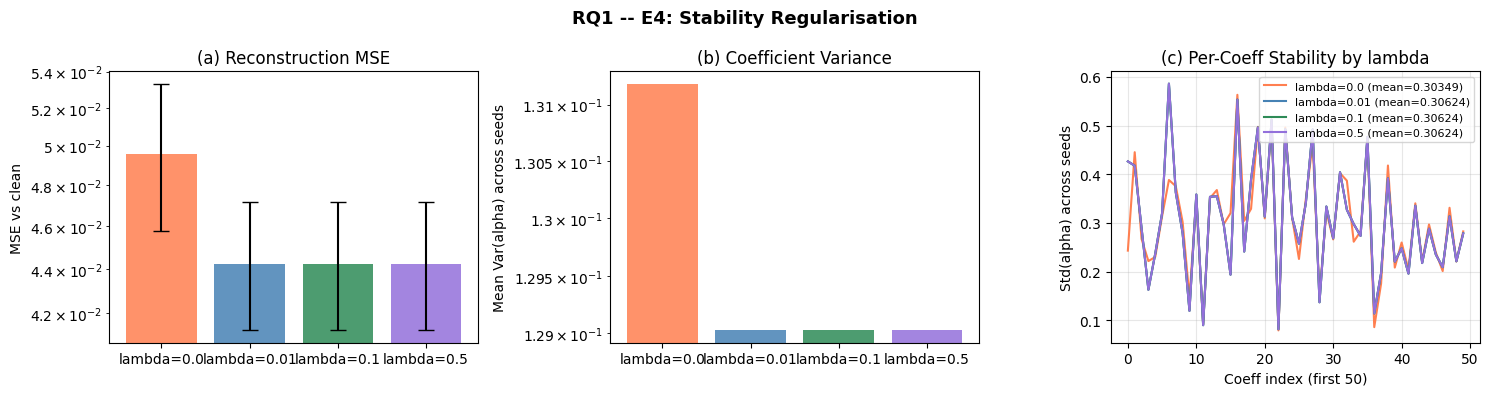

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lam_colors = {0.0:'coral', 0.01:'steelblue', 0.1:'seagreen', 0.5:'mediumpurple'}
lam_labels = [f'lambda={l}' for l in LAMBDA_VALUES]

ax = axes[0]
ax.bar(lam_labels, [e4[l]['mse_mean'] for l in LAMBDA_VALUES],
       yerr=[e4[l]['mse_std'] for l in LAMBDA_VALUES], capsize=6,
       color=[lam_colors[l] for l in LAMBDA_VALUES], alpha=0.85)
ax.set(ylabel='MSE vs clean', title='(a) Reconstruction MSE', yscale='log')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(lam_labels, [e4[l]['coeff_var'] for l in LAMBDA_VALUES],
       color=[lam_colors[l] for l in LAMBDA_VALUES], alpha=0.85)
ax.set(ylabel='Mean Var(alpha) across seeds', title='(b) Coefficient Variance', yscale='log')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[2]
for lam in LAMBDA_VALUES:
    std_v = e4[lam]['coeffs'].std(axis=0)[:50]
    ax.plot(std_v, color=lam_colors[lam], linewidth=1.5,
            label=f'lambda={lam} (mean={std_v.mean():.5f})')
ax.set(xlabel='Coeff index (first 50)', ylabel='Std(alpha) across seeds',
       title='(c) Per-Coeff Stability by lambda')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('RQ1 -- E4: Stability Regularisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq1_results/e4_stab_reg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E5 — Two-Body: Time-Invariant vs Time-Varying

The time-invariant model has a shared `coeff_param` nn.Parameter — this is the identifiable quantity we compare across seeds.

In [12]:
TB_SEEDS  = list(range(5))
TB_EPOCHS = 10
TB_BS     = 30

ti_losses, tv_losses, ti_params = [], [], []

for seed in TB_SEEDS:
    torch.manual_seed(seed); np.random.seed(seed)

    print(f'\n--- Seed {seed} --- Time-Invariant ---')
    m_ti, dm = ti_module.build_model(batch_size=TB_BS, solver_dbl=False, learning_rate=1e-4)
    pl.Trainer(max_epochs=TB_EPOCHS,
               accelerator='gpu' if torch.cuda.is_available() else 'cpu',
               devices=1, check_val_every_n_epoch=10,
               log_every_n_steps=500, enable_model_summary=False
               ).fit(m_ti, datamodule=dm)
    vl_ti = float(m_ti.trainer.logged_metrics.get('val_loss_epoch', float('nan')))
    cp = m_ti.model.coeff_param.detach().cpu().numpy().flatten()
    ti_losses.append(vl_ti); ti_params.append(cp)
    print(f'  val_loss={vl_ti:.6f}')

    print(f'--- Seed {seed} --- Time-Varying ---')
    m_tv, dm = tv_module.build_model(batch_size=TB_BS, solver_dbl=False, learning_rate=1e-4)
    pl.Trainer(max_epochs=TB_EPOCHS,
               accelerator='gpu' if torch.cuda.is_available() else 'cpu',
               devices=1, check_val_every_n_epoch=10,
               log_every_n_steps=500, enable_model_summary=False
               ).fit(m_tv, datamodule=dm)
    vl_tv = float(m_tv.trainer.logged_metrics.get('val_loss_epoch', float('nan')))
    tv_losses.append(vl_tv)
    print(f'  val_loss={vl_tv:.6f}')

ti_params = np.stack(ti_params)
ti_var    = ti_params.var(axis=0)
normed_ti = ti_params / (np.linalg.norm(ti_params, axis=1, keepdims=True) + 1e-12)
cos_ti    = normed_ti @ normed_ti.T

print(f'\nE5 Summary:')
print(f'  TI val_loss: {np.nanmean(ti_losses):.6f}+-{np.nanstd(ti_losses):.6f}')
print(f'  TV val_loss: {np.nanmean(tv_losses):.6f}+-{np.nanstd(tv_losses):.6f}')
print(f'  coeff_param var: mean={ti_var.mean():.8f}  max={ti_var.max():.8f}')
mask = ~np.eye(len(TB_SEEDS), dtype=bool)
print(f'  Cosine sim mean(off-diag)={cos_ti[mask].mean():.6f}')


--- Seed 0 --- Time-Invariant ---
Using single precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Epoch 9: 100%|██████████| 63/63 [01:32<00:00,  0.68it/s, v_num=80, train_loss_step=0.00374, train_loss_epoch=0.00347]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 9: 100%|██████████| 63/63 [02:16<00:00,  0.46it/s, v_num=80, train_loss_step=0.00374, train_loss_epoch=0.00279, val_loss_step=0.000305, val_loss_epoch=0.00256]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 63/63 [02:16<00:00,  0.46it/s, v_num=80, train_loss_step=0.00374, train_loss_epoch=0.00279, val_loss_step=0.000305, val_loss_epoch=0.00256]
  val_loss=0.002559
--- Seed 0 --- Time-Varying ---
Using single precision solver
Building block diagonal A


...

Epoch 9: 100%|██████████| 63/63 [02:30<00:00,  0.42it/s, v_num=88, train_loss_step=0.0156, train_loss_epoch=0.0175, val_loss_step=0.0181, val_loss_epoch=0.0243]
  val_loss=0.024252
--- Seed 4 --- Time-Varying ---
Using single precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Epoch 9: 100%|██████████| 63/63 [02:12<00:00,  0.48it/s, v_num=89, train_loss_step=0.0211, train_loss_epoch=0.0135]   
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 9: 100%|██████████| 63/63 [03:12<00:00,  0.33it/s, v_num=89, train_loss_step=0.0211, train_loss_epoch=0.016, val_loss_step=0.00776, val_loss_epoch=0.0224] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 63/63 [03:12<00:00,  0.33it/s, v_num=89, train_loss_step=0.0211, train_loss_epoch=0.016, val_loss_step=0.00776, val_loss_epoch=0.0224]
  val_loss=0.022358

E5 Summary:
  TI val_loss: 0.013533+-0.009588
  TV val_loss: 0.007505+-0.007495
  coeff_param var: mean=0.06699663  max=0.19324954
  Cosine sim mean(off-diag)=0.748829


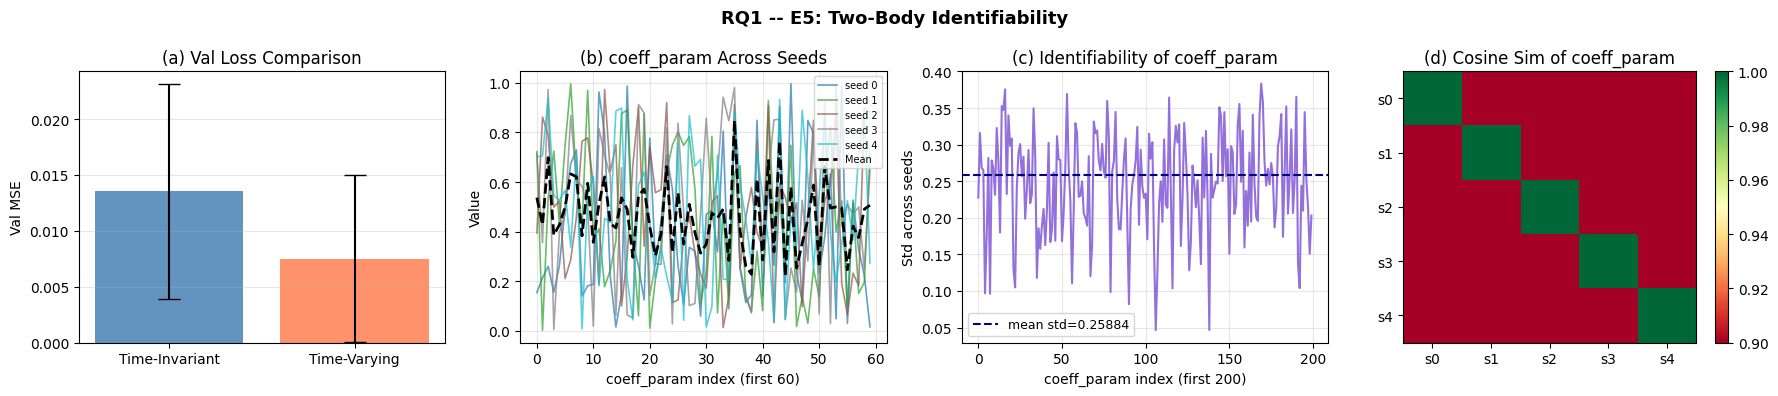

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

ax = axes[0]
ax.bar(['Time-Invariant','Time-Varying'],
       [np.nanmean(ti_losses), np.nanmean(tv_losses)],
       yerr=[np.nanstd(ti_losses), np.nanstd(tv_losses)],
       color=['steelblue','coral'], capsize=8, alpha=0.85)
ax.set(ylabel='Val MSE', title='(a) Val Loss Comparison'); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
cmap_s = plt.cm.tab10(np.linspace(0,1,len(TB_SEEDS)))
for i, cp in enumerate(ti_params):
    ax.plot(cp[:60], color=cmap_s[i], alpha=0.7, linewidth=1.2, label=f'seed {TB_SEEDS[i]}')
ax.plot(ti_params[:,:60].mean(axis=0), 'k--', linewidth=2, label='Mean')
ax.set(xlabel='coeff_param index (first 60)', ylabel='Value',
       title='(b) coeff_param Across Seeds')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(ti_var[:200]**0.5, color='mediumpurple', linewidth=1.5)
ax.axhline(ti_var.mean()**0.5, linestyle='--', color='navy', linewidth=1.5,
           label=f'mean std={ti_var.mean()**0.5:.5f}')
ax.set(xlabel='coeff_param index (first 200)', ylabel='Std across seeds',
       title='(c) Identifiability of coeff_param')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[3]
im = ax.imshow(cos_ti, vmin=0.9, vmax=1.0, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(TB_SEEDS))); ax.set_yticks(range(len(TB_SEEDS)))
ax.set_xticklabels([f's{i}' for i in TB_SEEDS])
ax.set_yticklabels([f's{i}' for i in TB_SEEDS])
ax.set_title('(d) Cosine Sim of coeff_param')

fig.suptitle('RQ1 -- E5: Two-Body Identifiability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq1_results/e5_two_body.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Full Summary Table

In [14]:
rows = []
for _, r in df_e1g.iterrows():
    rows.append({'Exp':'E1 Noise','Condition':f'sigma={r.noise_std}',
                 'MSE_mean':r.mse_mean,'MSE_std':r.mse_std,'Coeff_var':r.coeff_var})
for _, r in df_e2g.iterrows():
    rows.append({'Exp':'E2 Sparse','Condition':f'sub={r.subsample}(T={r.n_steps})',
                 'MSE_mean':r.mse_mean,'MSE_std':r.mse_std,'Coeff_var':r.coeff_var})
rows.append({'Exp':'E3 Stability','Condition':f'{N_STAB_SEEDS} seeds sigma=0.5',
             'MSE_mean':np.mean(e3_mses),'MSE_std':np.std(e3_mses),'Coeff_var':float(c_var.mean())})
for lam in LAMBDA_VALUES:
    rows.append({'Exp':'E4 StabReg','Condition':f'lambda={lam}',
                 'MSE_mean':e4[lam]['mse_mean'],'MSE_std':e4[lam]['mse_std'],
                 'Coeff_var':e4[lam]['coeff_var']})
rows.append({'Exp':'E5 Two-Body','Condition':'time-invariant',
             'MSE_mean':np.nanmean(ti_losses),'MSE_std':np.nanstd(ti_losses),
             'Coeff_var':float(ti_var.mean())})
rows.append({'Exp':'E5 Two-Body','Condition':'time-varying',
             'MSE_mean':np.nanmean(tv_losses),'MSE_std':np.nanstd(tv_losses),
             'Coeff_var':float('nan')})

df_summary = pd.DataFrame(rows)
df_summary.to_csv('rq1_results/rq1_full_summary.csv', index=False)
print('=== RQ1 Full Summary ===')
print(df_summary.to_string(index=False))

=== RQ1 Full Summary ===
         Exp         Condition  MSE_mean  MSE_std  Coeff_var
    E1 Noise         sigma=0.0  0.001160 0.000882   0.121264
    E1 Noise         sigma=0.1  0.002692 0.001053   0.121737
    E1 Noise         sigma=0.3  0.016252 0.002371   0.125933
    E1 Noise         sigma=0.5  0.048115 0.007380   0.132536
    E1 Noise         sigma=1.0  0.223744 0.037850   0.162029
    E1 Noise         sigma=2.0  1.167613 0.198854   0.217865
   E2 Sparse  sub=1.0(T=500.0)  0.048115 0.007380   0.132536
   E2 Sparse  sub=2.0(T=250.0)  0.064549 0.012856   0.130751
   E2 Sparse  sub=4.0(T=125.0)  0.082946 0.011218   0.122576
   E2 Sparse   sub=8.0(T=63.0)  0.083036 0.009148   0.119739
E3 Stability 8 seeds sigma=0.5  0.048807 0.003526   0.145045
  E4 StabReg        lambda=0.0  0.049549 0.003780   0.131184
  E4 StabReg       lambda=0.01  0.044214 0.002944   0.129026
  E4 StabReg        lambda=0.1  0.044214 0.002944   0.129026
  E4 StabReg        lambda=0.5  0.044215 0.002942   0.129026